In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
class Kinetic_Monte_Carlo():
    def __init__(self,Kon,Koff,L0):
        self.Kon = Kon
        self.Koff = Koff
        self.length = L0
        self.time = 0
        self.lengths = [L0]
        self.times = [0]
    def simulate(self,steps):
        k = self.Kon + self.Koff
        for i in range(steps):
            p = np.random.rand()
            p2 = np.random.rand()
            t = -np.log(p2)/k
            if 0 <= p < (self.Kon/k):
                self.length += 1 
                self.time += t
                self.lengths.append(self.length)
                self.times.append(self.time)
            elif (self.Kon/k) <= p < 1:
                if self.length > 0:
                    self.length -= 1
                self.lengths.append(self.length)
                self.time += t
                self.times.append(self.time)
        return np.array(self.lengths), np.array(self.times)
    def plot(self):
        plt.plot(self.times,self.lengths)
        plt.xlabel("Time")
        plt.ylabel("Length of Actin")
        # plt.show()

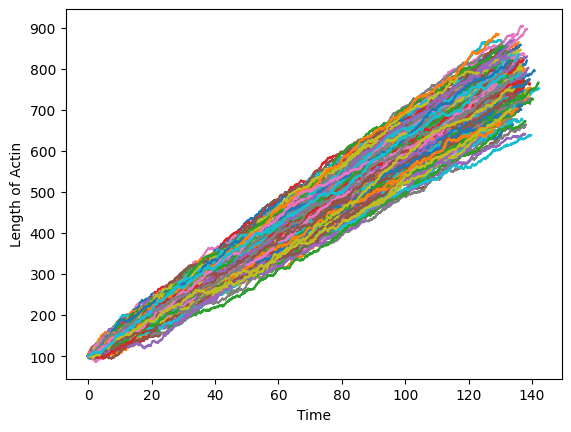

float64 (500, 2001)
float64 (500, 2001)


In [3]:
N = 500 #here I choose N = 500
times_union = np.array([])
all_times = np.ndarray((N,2001))
all_lengths = np.ndarray((N,2001))
for i in range(N):  
    KM = Kinetic_Monte_Carlo(10,5,100)
    lengths, times = KM.simulate(2000)
    # print(lengths.shape, times.shape)
    all_times[i] = times
    all_lengths[i] = lengths
    times_union = np.union1d(times_union,ar2=times)
    KM.plot()
plt.show()
print(all_times.dtype, all_times.shape)
print(all_lengths.dtype, all_lengths.shape)

In [4]:
from scipy import interpolate

complete_lengths = np.zeros((N,times_union.shape[0]))
for i in range(N):
    f = interpolate.interp1d(all_times[i],all_lengths[i],kind='previous',fill_value='extrapolate')
    complete_lengths[i] = f(times_union)
mean_lengths = np.mean(complete_lengths,axis=0)
variance_lengths = np.var(complete_lengths,axis=0)


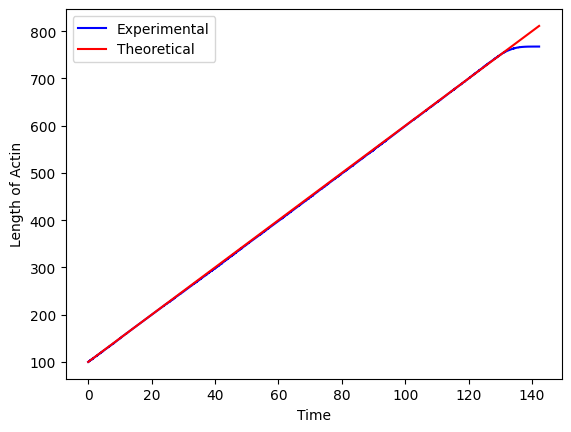

In [5]:

plt.plot(times_union,mean_lengths,label='Experimental', color = 'blue')
plt.plot(times_union,100 + 5 * times_union, label='Theoretical', color = 'red')
plt.xlabel("Time")
plt.ylabel("Length of Actin")
plt.legend()
plt.show()

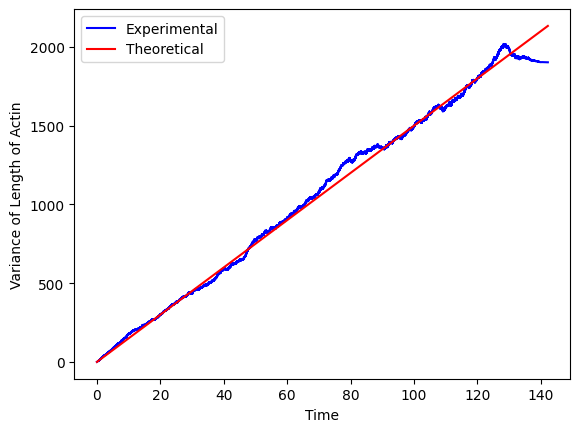

In [6]:
plt.plot(times_union,variance_lengths,label='Experimental', color = 'blue')
plt.plot(times_union,15 * times_union, label='Theoretical', color = 'red')
plt.xlabel("Time")
plt.ylabel("Variance of Length of Actin")
plt.legend()
plt.show()